<a href="https://colab.research.google.com/github/mrutunjaysenapati2005-spec/PRODIGY_ML_03/blob/main/Task3_SVM_CatsDogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import zipfile
import os

print("Extracting... please wait")
with zipfile.ZipFile(
    '/content/drive/MyDrive/train.zip', 'r') as z:
    z.extractall('/content/train_data/')

print("✅ Extracted!")
files = os.listdir('/content/train_data/train')
print(f"Total images: {len(files)}")
print("Sample:", files[:5])

Extracting... please wait
✅ Extracted!
Total images: 25000
Sample: ['dog.1681.jpg', 'cat.8621.jpg', 'dog.2861.jpg', 'dog.477.jpg', 'cat.912.jpg']


In [ ]:
import numpy as np
import cv2
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

IMG_SIZE = 64
MAX_IMAGES = 2000

data = []
labels = []

train_dir = '/content/train_data/train/'
all_files = os.listdir(train_dir)[:MAX_IMAGES]

print("Loading images...")
for i, fname in enumerate(all_files):
    label = 0 if fname.startswith('cat') else 1
    img_path = os.path.join(train_dir, fname)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    data.append(img.flatten())
    labels.append(label)
    if i % 500 == 0:
        print(f"  Loaded {i} images...")

X = np.array(data)
y = np.array(labels)
print(f"✅ Done! Shape: {X.shape}")
print(f"Cats: {sum(y==0)}, Dogs: {sum(y==1)}")

Loading images...
  Loaded 0 images...
  Loaded 500 images...
  Loaded 1000 images...
  Loaded 1500 images...
✅ Done! Shape: (2000, 4096)
Cats: 961, Dogs: 1039


In [ ]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training SVM...")
print("Please wait 3-5 minutes...")
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
print("✅ SVM Trained!")

Training SVM...
Please wait 3-5 minutes...
✅ SVM Trained!


In [ ]:
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=" * 40)
print("     MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"  Accuracy : {acc*100:.2f}%")
print("=" * 40)
print(classification_report(y_test, y_pred,
      target_names=['Cat', 'Dog']))

     MODEL PERFORMANCE RESULTS
  Accuracy : 65.00%
              precision    recall  f1-score   support

         Cat       0.69      0.56      0.62       203
         Dog       0.62      0.74      0.68       197

    accuracy                           0.65       400
   macro avg       0.66      0.65      0.65       400
weighted avg       0.66      0.65      0.65       400



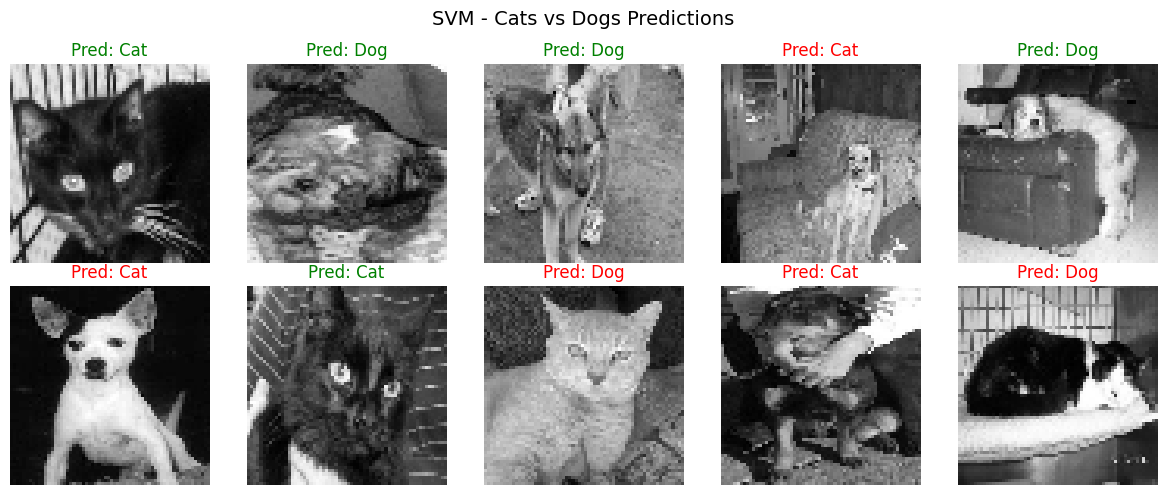

✅ Green=Correct  Red=Wrong


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('SVM - Cats vs Dogs Predictions',
             fontsize=14)

for i, ax in enumerate(axes.flat):
    img = X_test[i]
    orig = scaler.inverse_transform([img])[0]
    orig = orig.reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(orig, cmap='gray')
    color = 'green' if y_test[i]==y_pred[i] else 'red'
    label = 'Dog' if y_pred[i]==1 else 'Cat'
    ax.set_title(f'Pred: {label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("✅ Green=Correct  Red=Wrong")

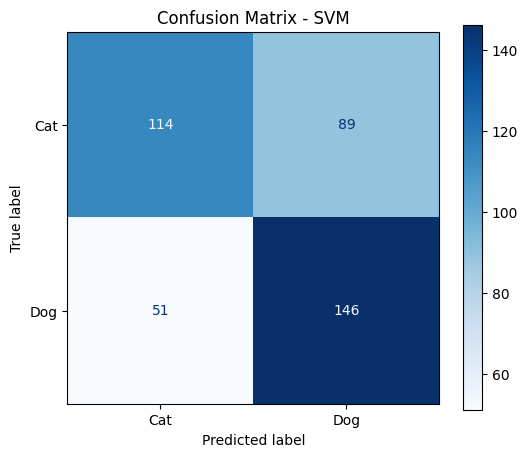

✅ Confusion Matrix done!


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Cat', 'Dog'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()
print("✅ Confusion Matrix done!")